In [3]:
!pip install graphviz

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('heart.csv')
X = df.drop(columns=['target'])
y = df['target']

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


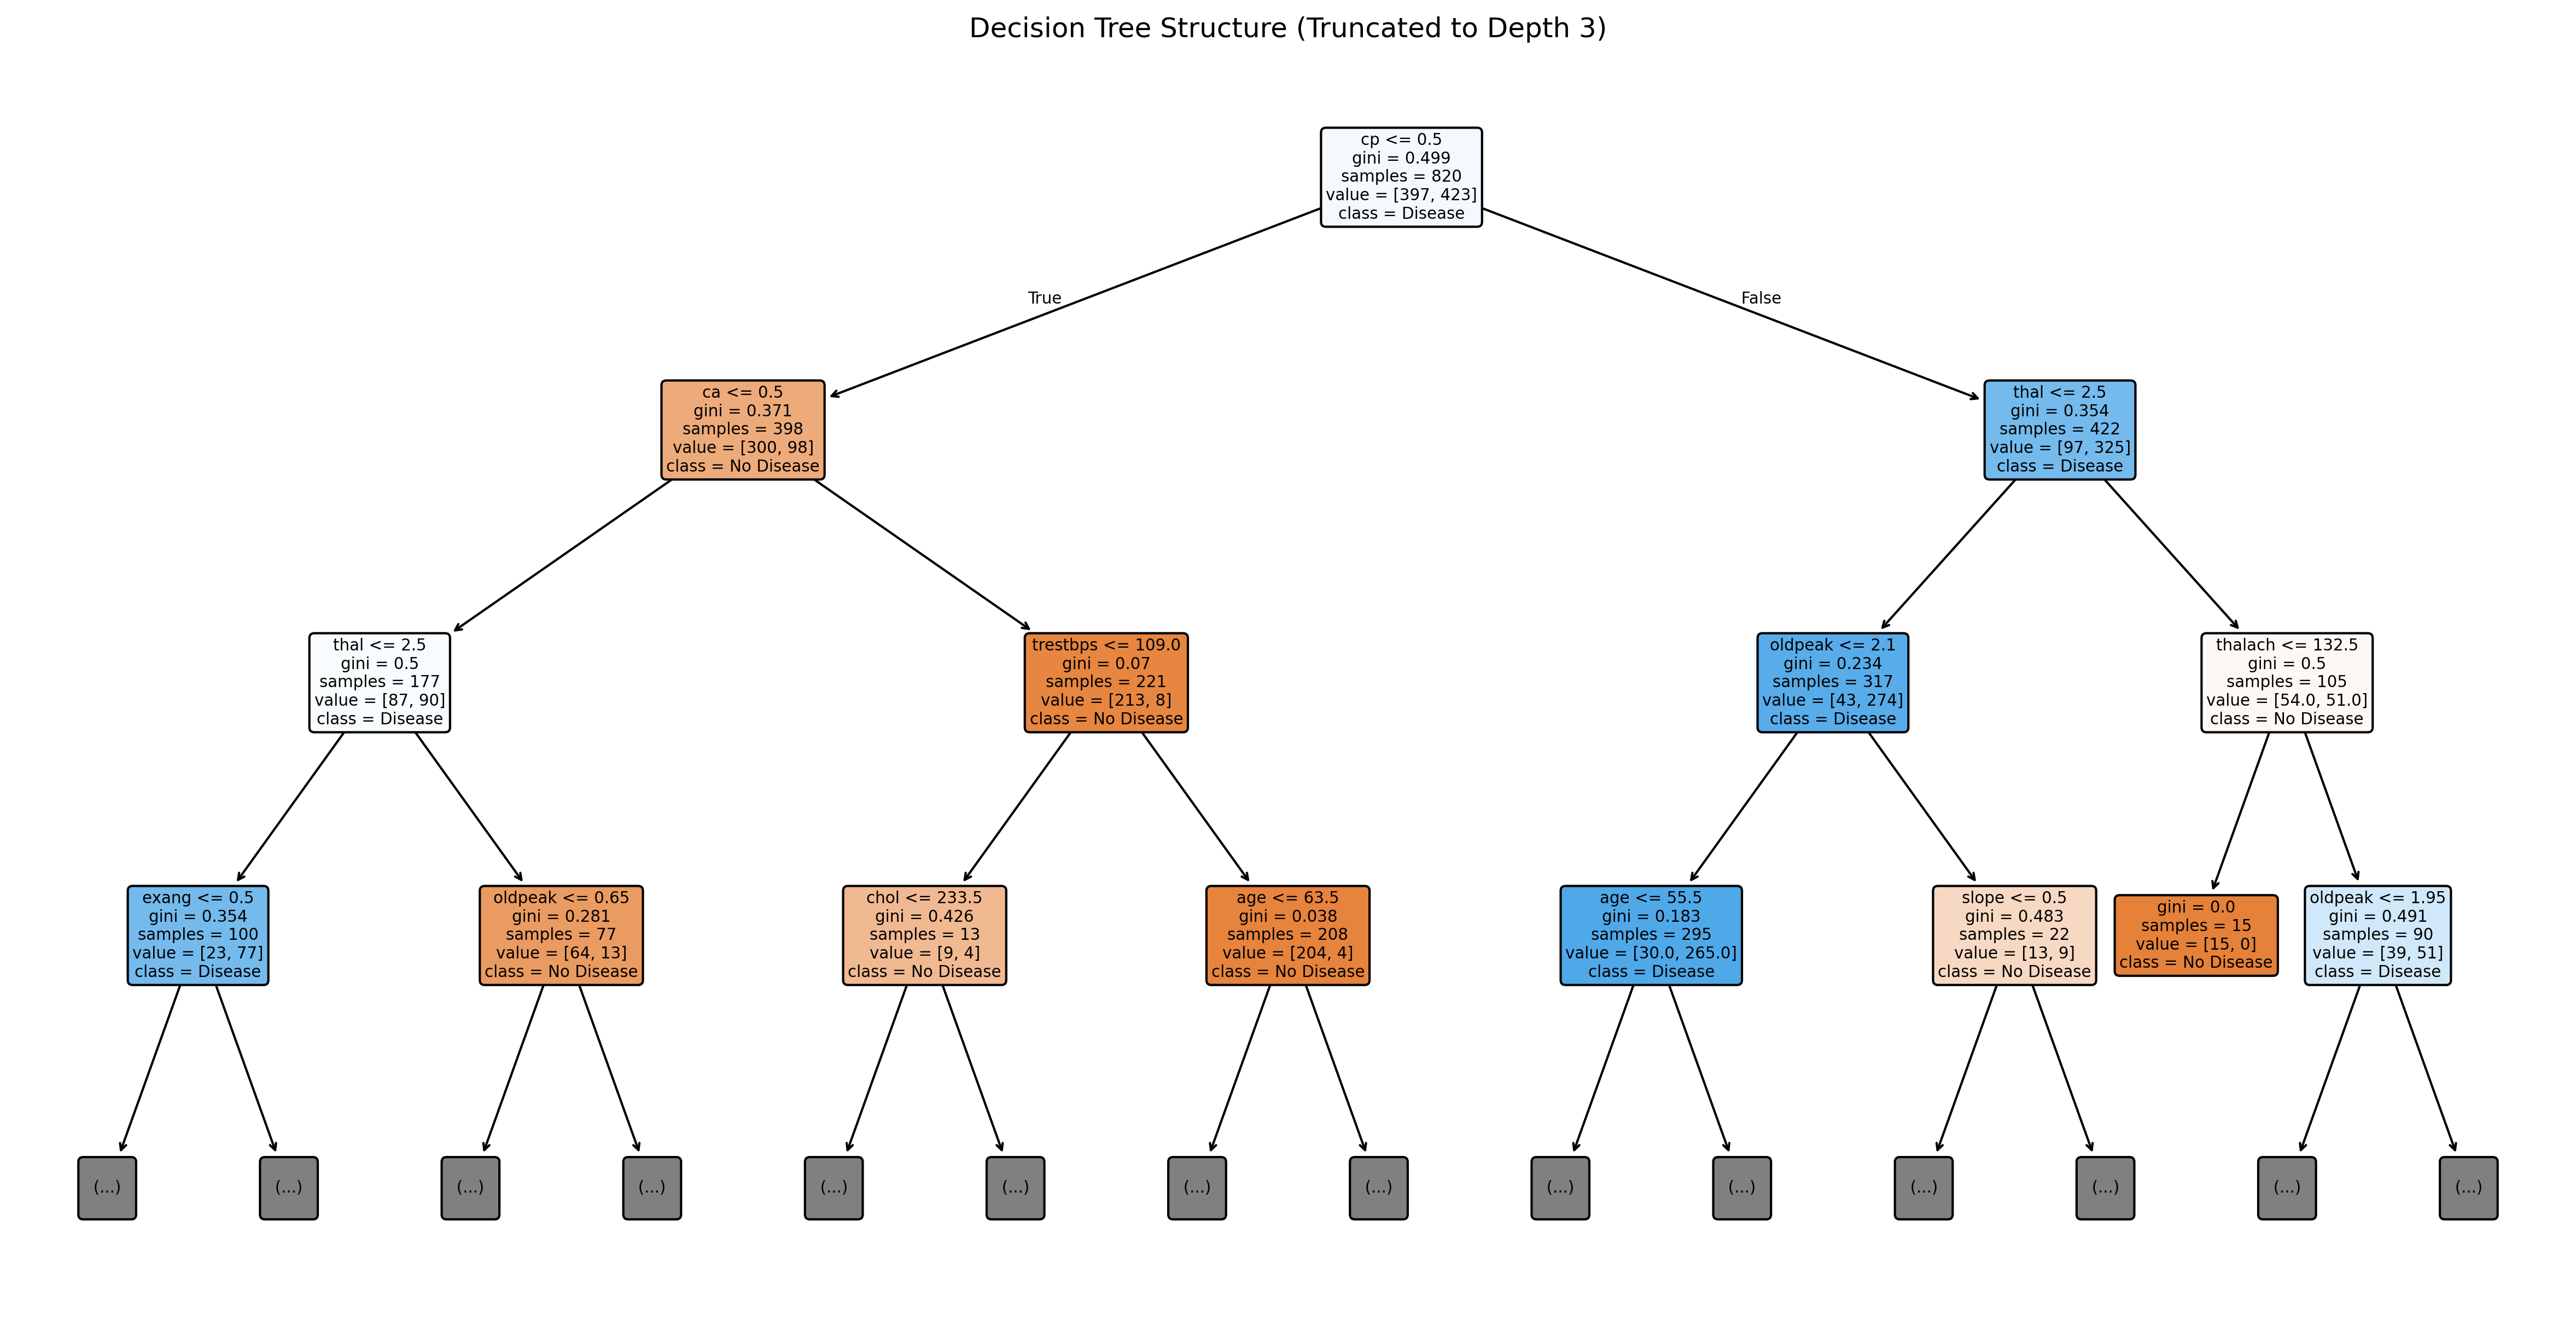

Tree trained and saved to 'heart_tree.png'


In [10]:
# Testing and Traing models 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt_unconstrained = DecisionTreeClassifier(random_state=42)
dt_unconstrained.fit(X_train, y_train)

# Visualize using matplotlib 

plt.figure(figsize=(20, 10), dpi=300)
plot_tree(
    dt_unconstrained, 
    max_depth=3,  # Limits visual clutter while plotting
    feature_names=list(X.columns), 
    class_names=['No Disease', 'Disease'], 
    filled=True, 
    rounded=True
)
plt.title("Decision Tree Structure (Truncated to Depth 3)")
plt.savefig('heart_tree.png', bbox_inches='tight')
plt.show()
print("Tree trained and saved to 'heart_tree.png'")


In [15]:
# Control Depth & Analyze Overfitting

dt_pruned = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_pruned.fit(X_train, y_train)

print("Overfitting Analysis ---")
print(f"Unconstrained Tree - Train Accuracy: {dt_unconstrained.score(X_train, y_train):.4f}")
print(f"Unconstrained Tree - Test Accuracy:  {dt_unconstrained.score(X_test, y_test):.4f}")
print(f"Pruned Tree (Depth=3) - Train Accuracy: {dt_pruned.score(X_train, y_train):.4f}")
print(f"Pruned Tree (Depth=3) - Test Accuracy:  {dt_pruned.score(X_test, y_test):.4f}")

Overfitting Analysis ---
Unconstrained Tree - Train Accuracy: 1.0000
Unconstrained Tree - Test Accuracy:  0.9854
Pruned Tree (Depth=3) - Train Accuracy: 0.8512
Pruned Tree (Depth=3) - Test Accuracy:  0.7805


In [14]:
# Train Random Forest & Compare

rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

print("Random Forest Comparison ---")
print(f"Random Forest - Train Accuracy: {rf_model.score(X_train, y_train):.4f}")
print(f"Random Forest - Test Accuracy:  {rf_model.score(X_test, y_test):.4f}")

Random Forest Comparison ---
Random Forest - Train Accuracy: 0.9537
Random Forest - Test Accuracy:  0.8732


In [17]:
# Interpret Feature Importances

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("Feature Rankings ---")
for f in range(5):  # Show top 5 features
    print(f"{f + 1}. Feature '{X.columns[indices[f]]}' ({importances[indices[f]]:.4f})")


Feature Rankings ---
1. Feature 'cp' (0.1645)
2. Feature 'thal' (0.1473)
3. Feature 'ca' (0.1462)
4. Feature 'oldpeak' (0.1299)
5. Feature 'thalach' (0.1118)


In [18]:
# Evaluate Using Cross-Validation

cv_scores = cross_val_score(rf_model, X, y, cv=5)

print("5-Fold Cross-Validation ---")
print(f"All 5 CV Scores: {cv_scores}")
print(f"Mean Cross-Validation Accuracy: {cv_scores.mean():.4f}")

5-Fold Cross-Validation ---
All 5 CV Scores: [0.97073171 0.91219512 0.95121951 0.91219512 0.90243902]
Mean Cross-Validation Accuracy: 0.9298
